In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("ab_test.csv")

In [9]:
df

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1
...,...,...,...,...,...
294473,751197,28:38.6,control,old_page,0
294474,945152,51:57.1,control,old_page,0
294475,734608,45:03.4,control,old_page,0
294476,697314,20:29.0,control,old_page,0


In [10]:
print("shape:", df.shape)

shape: (294478, 5)


In [11]:
print("columns:", df.columns.tolist())

columns: ['id', 'time', 'con_treat', 'page', 'converted']


In [12]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 7.9+ MB


None

In [14]:
df["time_seconds"] = (
    df["time"].str.split(":").str[0].astype(float) * 60 +
    df["time"].str.split(":").str[1].astype(float))

In [15]:
df[["time", "time_seconds"]].head()

,time,time_seconds
0,11:48.6,708.6
1,01:45.2,105.2
2,55:06.2,3306.2
3,28:03.1,1683.1
4,52:26.2,3146.2


In [16]:
df["time_seconds"].describe()

count    294478.000000
mean       1803.134724
std        1038.200386
min           0.000000
25%         904.900000
50%        1803.400000
75%        2701.600000
max        3599.900000
Name: time_seconds, dtype: float64

In [17]:
display(df.isna().sum())

id              0
time            0
con_treat       0
page            0
converted       0
time_seconds    0
dtype: int64

In [19]:
print("\ncon_treat value counts:")
print(df["con_treat"].value_counts(dropna=False))


con_treat value counts:
con_treat
treatment    147276
control      147202
Name: count, dtype: int64


In [20]:
print("\npage value counts:")
print(df["page"].value_counts(dropna=False))


page value counts:
page
old_page    147239
new_page    147239
Name: count, dtype: int64


In [21]:
print("\nconverted value counts:")
print(df["converted"].value_counts(dropna=False))


converted value counts:
converted
0    259241
1     35237
Name: count, dtype: int64


In [22]:
pd.crosstab(df["con_treat"], df["page"])

page,new_page,old_page
con_treat,,
control,1928,145274
treatment,145311,1965


In [23]:
df_clean = df[
    ((df["con_treat"] == "control") & (df["page"] == "old_page")) |
    ((df["con_treat"] == "treatment") & (df["page"] == "new_page"))
].copy()

In [24]:
pd.crosstab(df_clean["con_treat"], df_clean["page"])

page,new_page,old_page
con_treat,,
control,0,145274
treatment,145311,0


In [25]:
df_clean.shape

(290585, 6)

In [26]:
# Explanation: Check whether user IDs are unique after cleaning.
# If the same user appears multiple times, we need a rule to handle duplicates.

dup_count = df_clean.duplicated(subset=["id"]).sum()
total = df_clean.shape[0]
unique_users = df_clean["id"].nunique()

print("Rows:", total)
print("Unique users:", unique_users)
print("Duplicate IDs (extra rows):", dup_count)

Rows: 290585
Unique users: 290584
Duplicate IDs (extra rows): 1


In [28]:
# Explanation: If duplicates exist, inspect a few examples to understand why
# (same user repeated, possibly different timestamps or conflicting conversion values).
dup_examples = df_clean[df_clean.duplicated(subset=["id"], keep=False)].sort_values("id")
display(dup_examples.head(10))

,id,time,con_treat,page,converted,time_seconds
1899,773192,37:58.8,treatment,new_page,0,2278.8
2893,773192,55:59.6,treatment,new_page,0,3359.6


In [29]:
# Explanation: Build a user-level dataset (1 row per user).
# Rule: a user is converted if they have at least one converted=1.
# We also keep the earliest observed time_seconds for reference.

df_user = (
    df_clean.sort_values("time_seconds")
            .groupby("id", as_index=False)
            .agg(
                con_treat=("con_treat", "first"),
                page=("page", "first"),
                converted=("converted", "max"),
                time_seconds=("time_seconds", "min")
            )
)

print("Rows (user-level):", df_user.shape[0])
print("Unique users:", df_user["id"].nunique())
print("Any duplicate ids left:", df_user.duplicated(subset=["id"]).any())

Rows (user-level): 290584
Unique users: 290584
Any duplicate ids left: False


In [30]:
# Explanation: Sanity check that the group↔page mapping is still clean after deduplication.

pd.crosstab(df_user["con_treat"], df_user["page"])

page,new_page,old_page
con_treat,,
control,0,145274
treatment,145310,0


In [31]:
# Explanation: Quick check that converted is binary (0/1) and distribution looks reasonable.

print(df_user["converted"].value_counts(dropna=False))

converted
0    255831
1     34753
Name: count, dtype: int64


In [32]:
# Explanation: Calculate number of users, number of conversions,
# and conversion rate for each experiment group.

ab_summary = (
    df_user
    .groupby("con_treat")
    .agg(
        users=("id", "count"),
        conversions=("converted", "sum")
    )
)

ab_summary["conversion_rate"] = ab_summary["conversions"] / ab_summary["users"]

display(ab_summary)

,users,conversions,conversion_rate
con_treat,,,
control,145274,17489,0.120386
treatment,145310,17264,0.118808


In [33]:
# Explanation: Calculate absolute uplift (difference in conversion rates)
# between treatment and control.

cr_control = ab_summary.loc["control", "conversion_rate"]
cr_treatment = ab_summary.loc["treatment", "conversion_rate"]

absolute_uplift = cr_treatment - cr_control

print("CR control:", cr_control)
print("CR treatment:", cr_treatment)
print("Absolute uplift:", absolute_uplift)

CR control: 0.1203863045004612
CR treatment: 0.11880806551510564
Absolute uplift: -0.0015782389853555567


In [34]:
# Explanation: Calculate relative uplift (percentage improvement).

relative_uplift = absolute_uplift / cr_control

print("Relative uplift:", relative_uplift)

Relative uplift: -0.01310978845894809


In [35]:
# Explanation: Import statistical test for comparing two proportions
# (used to test difference in conversion rates between groups).

from statsmodels.stats.proportion import proportions_ztest

In [36]:
# Explanation: Prepare the data for the statistical test.
# We need number of conversions and total users in each group.

conversions = ab_summary["conversions"].values
users = ab_summary["users"].values

print("Conversions:", conversions)
print("Users:", users)

Conversions: [17489 17264]
Users: [145274 145310]


In [37]:
# Explanation: Run two-proportion z-test to check whether the difference
# in conversion rates is statistically significant.

z_stat, p_value = proportions_ztest(conversions, users)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.3109241984234394
P-value: 0.18988337448195103


In [38]:
# Explanation: Import function to calculate confidence interval
# for difference between two conversion rates.

from statsmodels.stats.proportion import confint_proportions_2indep

In [39]:
# Explanation: Extract number of conversions and users for each group.

conv_control = ab_summary.loc["control", "conversions"]
users_control = ab_summary.loc["control", "users"]

conv_treat = ab_summary.loc["treatment", "conversions"]
users_treat = ab_summary.loc["treatment", "users"]

In [40]:
# Explanation: Calculate 95% confidence interval for the difference
# in conversion rates between treatment and control.

ci_low, ci_high = confint_proportions_2indep(
    conv_treat, users_treat,
    conv_control, users_control,
    method="wald"
)

print("95% CI lower:", ci_low)
print("95% CI upper:", ci_high)

95% CI lower: -0.003937860245052737
95% CI upper: 0.0007813822743416238


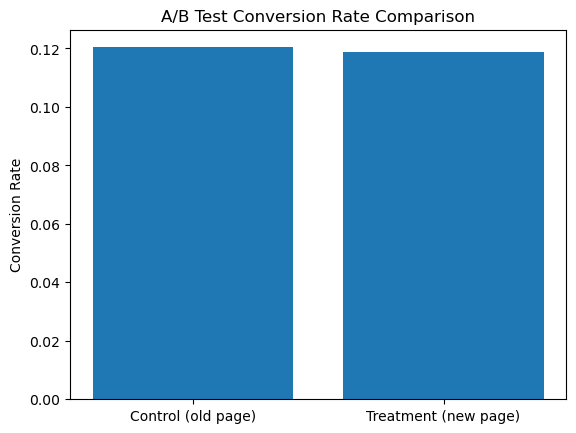

In [41]:
# Explanation: Plot conversion rates for control and treatment groups
# to visually compare experiment results.

import matplotlib.pyplot as plt

cr_values = [
    ab_summary.loc["control", "conversion_rate"],
    ab_summary.loc["treatment", "conversion_rate"]
]

groups = ["Control (old page)", "Treatment (new page)"]

plt.figure()
plt.bar(groups, cr_values)

plt.ylabel("Conversion Rate")
plt.title("A/B Test Conversion Rate Comparison")

plt.show()

In [42]:
# Explanation: Count number of users in control and treatment groups
# to verify the traffic allocation between experiment variants.

group_counts = df_user["con_treat"].value_counts()

control_users = group_counts["control"]
treatment_users = group_counts["treatment"]

print("Control users:", control_users)
print("Treatment users:", treatment_users)

Control users: 145274
Treatment users: 145310


In [43]:
# Explanation: Run chi-square test to check whether the observed traffic split
# significantly deviates from the expected 50/50 allocation.

from scipy.stats import chisquare

observed = [control_users, treatment_users]
expected = [sum(observed)/2, sum(observed)/2]

chi_stat, p_value_srm = chisquare(observed, expected)

print("Chi-square statistic:", chi_stat)
print("SRM p-value:", p_value_srm)

Chi-square statistic: 0.004459984032155934
SRM p-value: 0.9467543681597944


In [44]:
# Explanation: Import power analysis tool for proportion tests.
# This helps estimate how many users are needed to detect a meaningful effect.

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Explanation: Define baseline conversion rate and the minimum detectable effect (MDE).
# MDE is the smallest change in conversion rate that the business would care about.

baseline_cr = cr_control
mde = 0.01   # example: detect a 1 percentage point improvement

# Explanation: Calculate required sample size per group to detect the MDE
# with 80% statistical power and 5% significance level.

effect_size = proportion_effectsize(baseline_cr, baseline_cr + mde)

analysis = NormalIndPower()

required_sample = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

print("Required sample size per group:", round(required_sample))

Required sample size per group: 17209


In [45]:
# Explanation: Build a compact JSON payload with experiment results and diagnostics
# that we will send to the model to generate an executive A/B test report.

import json

ab_json = {
    "experiment": {
        "name": "Landing Page A/B Test",
        "objective": "Increase conversion rate (converted = 1).",
        "unit_of_analysis": "user_id",
        "variants": {
            "control": {"page": "old_page"},
            "treatment": {"page": "new_page"}
        }
    },
    "data_quality": {
        "initial_mismatch_rows_removed": 3893,
        "dedup_rule": "user is converted if converted=1 appears at least once; keep earliest time_seconds",
        "srm_check": {
            "control_users": int(control_users),
            "treatment_users": int(treatment_users),
            "chi_square_stat": float(chi_stat),
            "p_value": float(p_value_srm)
        }
    },
    "metrics": {
        "control": {
            "users": int(ab_summary.loc["control", "users"]),
            "conversions": int(ab_summary.loc["control", "conversions"]),
            "conversion_rate": float(cr_control)
        },
        "treatment": {
            "users": int(ab_summary.loc["treatment", "users"]),
            "conversions": int(ab_summary.loc["treatment", "conversions"]),
            "conversion_rate": float(cr_treatment)
        },
        "uplift": {
            "absolute": float(absolute_uplift),
            "relative": float(relative_uplift)
        }
    },
    "statistics": {
        "z_test": {
            "z_stat": float(z_stat),
            "p_value": float(p_value)
        },
        "ci_95_diff_cr_treat_minus_control": {
            "lower": float(ci_low),
            "upper": float(ci_high)
        },
        "power_analysis": {
            "assumptions": {"alpha": 0.05, "power": 0.8, "mde_absolute": 0.01},
            "required_sample_size_per_group": int(required_sample)
        }
    }
}

ab_json_str = json.dumps(ab_json, ensure_ascii=False, indent=2)
print(ab_json_str[:1200])  # preview

{
  "experiment": {
    "name": "Landing Page A/B Test",
    "objective": "Increase conversion rate (converted = 1).",
    "unit_of_analysis": "user_id",
    "variants": {
      "control": {
        "page": "old_page"
      },
      "treatment": {
        "page": "new_page"
      }
    }
  },
  "data_quality": {
    "initial_mismatch_rows_removed": 3893,
    "dedup_rule": "user is converted if converted=1 appears at least once; keep earliest time_seconds",
    "srm_check": {
      "control_users": 145274,
      "treatment_users": 145310,
      "chi_square_stat": 0.004459984032155934,
      "p_value": 0.9467543681597944
    }
  },
  "metrics": {
    "control": {
      "users": 145274,
      "conversions": 17489,
      "conversion_rate": 0.1203863045004612
    },
    "treatment": {
      "users": 145310,
      "conversions": 17264,
      "conversion_rate": 0.11880806551510564
    },
    "uplift": {
      "absolute": -0.0015782389853555567,
      "relative": -0.01310978845894809
    }
  }

In [46]:
# Explanation: Create a report prompt that forces a business-style output
# (decision, evidence, risks, next steps) and avoids generic fluff.

REPORT_PROMPT = f"""
You are a product analytics consultant. Generate a decision-ready executive report for an A/B test.

Rules:
- Use only the JSON facts provided; do not invent numbers.
- Be concise, business-first, and action-oriented.
- Include statistical interpretation (p-value, 95% CI), SRM validity, and power/sample size implications.
- Output in Markdown with clear headings and bullets.
- End with a one-line final decision.

JSON:
{ab_json_str}

Report structure:
1) Executive Summary (2-4 bullets)
2) Experiment Validity Checks (SRM, data cleaning notes)
3) Key Metrics (control vs treatment + uplift)
4) Statistical Conclusion (z-test + 95% CI interpretation)
5) Business Recommendation (rollout / keep / iterate)
6) Next Experiment Ideas (2-3 practical options)
"""

In [47]:
# Explanation: Call OpenAI Responses API to generate the executive report.
# Make sure OPENAI_API_KEY is set in your environment.

from openai import OpenAI

client = OpenAI()

resp = client.responses.create(
    model="gpt-5.2",   # or another available reasoning model
    input=REPORT_PROMPT,
)

report_md = resp.output_text
print(report_md[:2000])  # preview first part

<class 'openai.OpenAIError'>: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [48]:
# Explanation: Save the model's report to a Markdown file for your portfolio/GitHub.

with open("ab_executive_report.md", "w", encoding="utf-8") as f:
    f.write(report_md)

print("Saved to ab_executive_report.md")

<class 'NameError'>: name 'report_md' is not defined

In [49]:
# Explanation: Convert the generated Markdown report into a PDF file using Pandoc.

import subprocess

subprocess.run([
    "pandoc",
    "ab_executive_report.md",
    "-o",
    "ab_executive_report.pdf",
    "--pdf-engine=tectonic"
])

print("PDF generated: ab_executive_report.pdf")

<class 'OSError'>: [Errno 138] emscripten does not support processes.